# IBEX 35 Volatility: Stage 2 — Stationarity & Mean Model

Stage 1 established the stylized facts that motivate GARCH: returns look close
to unpredictable in the mean, but their *magnitude* is highly autocorrelated
(volatility clustering). Before jumping to GARCH, standard Box-Jenkins practice
is to first nail down the **mean model** — confirm the series is stationary,
identify a candidate ARIMA order, fit it, and check that its residuals are
clean. Only once the *linear, mean* structure has been dealt with does it make
sense to model what's left in the *variance*.

This notebook is self-contained: it re-downloads the same data as Stage 1
rather than importing it, so it can be run independently.

**Goals of this notebook**
1. Formally test stationarity (ADF and KPSS) on both price and return series.
2. Use ACF/PACF to guide ARIMA order identification.
3. Fit a mean model (ARIMA) to the returns and validate its residuals.
4. Show that even a clean mean-model residual still has autocorrelated
   *squared* residuals — the empirical bridge to GARCH in Stage 3.


## 1. Setup

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
import seaborn as sns
import yfinance as yf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller, kpss

# We deliberately do not blanket-silence warnings: convergence/numerical
# warnings and statsmodels' KPSS InterpolationWarning are informative and
# should surface. We only filter two specific, known-benign messages: a
# yfinance-internal pandas deprecation notice, and a cosmetic statsmodels
# notice about date-index frequency inference that floods output during
# pmdarima's model search.
warnings.filterwarnings("ignore", message="Timestamp.utcnow is deprecated.*")
warnings.filterwarnings("ignore", message="A date index has been provided.*")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100


## 2. Data

Same construction as Stage 1: ~10 years of daily closes for the IBEX 35
(`^IBEX`) and S&P 500 (`^GSPC`), adjusted for splits/dividends
(`auto_adjust=True`), with log returns $r_t = \ln(P_t / P_{t-1})$. See Stage 1
for the full discussion of why the index (not constituents), why this window
length, and why adjusted price-return series are the right inputs.


In [2]:
TICKERS = {"IBEX35": "^IBEX", "SP500": "^GSPC"}
END = pd.Timestamp("2026-07-01")
START = END - pd.DateOffset(years=10)

raw = yf.download(list(TICKERS.values()), start=START, end=END, auto_adjust=True, progress=False)
prices = raw["Close"].rename(columns={v: k for k, v in TICKERS.items()})
prices = prices.dropna(how="any")

log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.tail()


Ticker,SP500,IBEX35
Date,,
2026-06-24,-0.000983,-0.004477
2026-06-25,-0.000099,0.006380
2026-06-26,-0.000472,-0.004535
2026-06-29,0.011682,-0.001953
2026-06-30,0.007889,0.004349


## 3. Stationarity testing

A model like ARIMA assumes a **stationary** process — one whose mean, variance
and autocovariance structure don't drift over time. We already argued
informally in Stage 1 that prices trend (non-stationary) while returns don't
(stationary); here we confirm it formally with two complementary tests.

**Augmented Dickey-Fuller (ADF).** Tests the regression

$$
\Delta y_t = \alpha + \gamma\, y_{t-1} + \sum_{i=1}^{k} \delta_i \, \Delta y_{t-i} + \varepsilon_t
$$

with $H_0: \gamma = 0$ (a **unit root** — the series is non-stationary, shocks
have permanent effects) against $H_1: \gamma < 0$ (stationary, shocks decay).
**Low p-value → reject $H_0$ → conclude stationary.**

**KPSS.** Decomposes the series as $y_t = \xi t + r_t + \varepsilon_t$ where
$r_t$ is a random walk, and tests $H_0: \text{Var}(r_t) = 0$ — i.e. no random-walk
component, so the series is (trend-)stationary — against $H_1$: a unit root is
present. **This is the opposite null from ADF.** **Low p-value → reject $H_0$
→ conclude non-stationary; high p-value → stationary.**

**Why use both.** Each test's null hypothesis is what you get "by default" if
the test is inconclusive — ADF defaults to non-stationary, KPSS defaults to
stationary. Since only one is likely to be true, agreement between the two
(ADF rejects *and* KPSS fails to reject) gives a much more robust stationarity
conclusion than either test alone, and disagreement flags a series that needs
closer inspection (e.g. a trend-stationary series, or one near the boundary).


In [3]:
def stationarity_tests(series, name):
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    return {
        "Series": name,
        "ADF stat": adf_stat,
        "ADF p-value": adf_p,
        "ADF verdict": "Stationary" if adf_p < 0.05 else "Non-stationary",
        "KPSS stat": kpss_stat,
        "KPSS p-value": kpss_p,
        "KPSS verdict": "Stationary" if kpss_p > 0.05 else "Non-stationary",
    }


rows = []
for col in prices.columns:
    rows.append(stationarity_tests(prices[col], f"{col} — price"))
for col in log_returns.columns:
    rows.append(stationarity_tests(log_returns[col], f"{col} — log return"))

stationarity_df = pd.DataFrame(rows).set_index("Series")
stationarity_df


C:\Users\matia\AppData\Local\Temp\ipykernel_40428\495235350.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
C:\Users\matia\AppData\Local\Temp\ipykernel_40428\495235350.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")


C:\Users\matia\AppData\Local\Temp\ipykernel_40428\495235350.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
C:\Users\matia\AppData\Local\Temp\ipykernel_40428\495235350.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")


,ADF stat,ADF p-value,ADF verdict,KPSS stat,KPSS p-value,KPSS verdict
Series,,,,,,
SP500 — price,0.963679,9.938676e-01,Non-stationary,7.316141,0.01,Non-stationary
IBEX35 — price,1.815762,9.983798e-01,Non-stationary,3.505496,0.01,Non-stationary
SP500 — log return,-11.299600,1.317494e-20,Stationary,0.034612,0.10,Stationary
IBEX35 — log return,-17.672067,3.640913e-30,Stationary,0.307157,0.10,Stationary


**Interpretation.** The price series show a high ADF p-value (fail to reject
the unit-root null) together with a low KPSS p-value (reject the
stationarity null) — both tests agree the price levels are **non-stationary**,
as expected for a trending series. The log-return series flip both verdicts:
a very low ADF p-value (reject the unit root) together with a KPSS p-value
that does *not* reject stationarity — both tests agree returns **are
stationary**. This confirms log returns, not prices, are the right object to
model with ARIMA, and that no further differencing ($d=0$) is needed.


## 4. ACF / PACF — order identification

With stationarity confirmed, Box-Jenkins methodology uses the sample
autocorrelation function (ACF) and partial autocorrelation function (PACF) of
the returns to propose candidate ARIMA$(p, 0, q)$ orders:

- The **ACF** at lag $k$ measures total correlation between $r_t$ and
  $r_{t-k}$ (including indirect effects through intermediate lags) — a sharp
  cutoff after lag $q$ is the signature of an **MA($q$)** process.
- The **PACF** at lag $k$ measures the correlation between $r_t$ and $r_{t-k}$
  *after* removing the effect of the lags in between — a sharp cutoff after
  lag $p$ is the signature of an **AR($p$)** process.

In practice, for daily equity index returns we expect **both to be close to
flat and inside the confidence band at almost every lag** — a hallmark of a
process close to white noise. That's not a failure of the method; it is
itself informative: it tells us the mean model will be small (low $p, q$, quite
possibly $(0,0)$), because the *return* is close to unforecastable — consistent
with the near-zero ACF we already saw in Stage 1 and with weak-form market
efficiency.


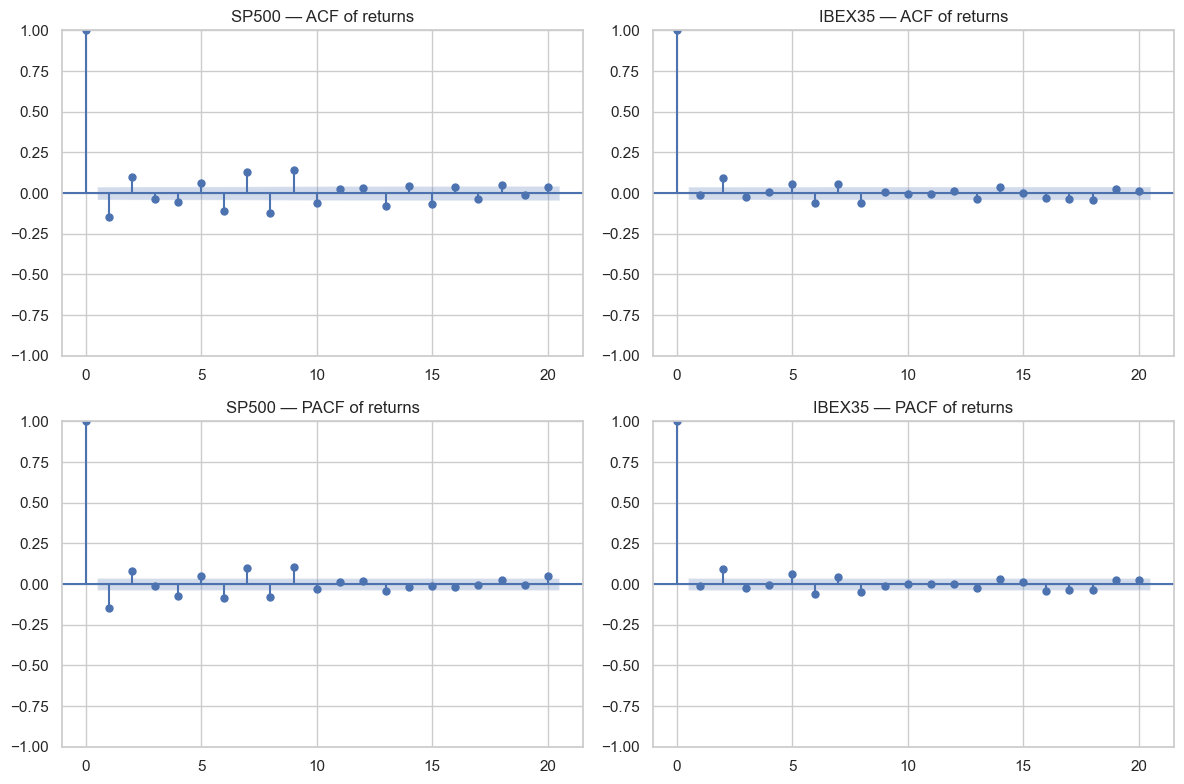

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
lags = 20

for j, col in enumerate(log_returns.columns):
    plot_acf(log_returns[col], lags=lags, ax=axes[0, j], title=f"{col} — ACF of returns")
    plot_pacf(log_returns[col], lags=lags, ax=axes[1, j], title=f"{col} — PACF of returns", method="ywm")

plt.tight_layout()
plt.show()


**Interpretation.** As anticipated, both ACF and PACF sit mostly inside the
significance band across the 20 lags shown, for both indices. There may be a
lone significant spike at very short lags (e.g. lag 1) — plausible
microstructure artifacts such as bid-ask bounce or non-synchronous trading
across the constituents that make up the index, rather than genuine
predictability. There is no sign of a slowly decaying pattern in either
function, which rules out the need for a rich AR or MA structure. This
pre-registers our expectation for the next step: the order search should land
on something small.


## 5. Mean model — ARIMA order selection

We let a stepwise AIC search (`pmdarima.auto_arima`) pick $(p, q)$ over a small
grid, with $d$ fixed at 0 since Section 3 already established the returns are
stationary — no differencing required. AIC trades off fit quality against
model complexity, which is what we want here: we're not trying to force
structure onto a series that has little of it, just to find the
best small model.


In [5]:
arima_models = {}
for col in log_returns.columns:
    print(f"\n=== {col} ===")
    model = pm.auto_arima(
        log_returns[col],
        start_p=0, start_q=0, max_p=5, max_q=5, d=0,
        seasonal=False, stepwise=True, information_criterion="aic",
        suppress_warnings=True, error_action="ignore", trace=True,
    )
    arima_models[col] = model
    print(model.summary())



=== SP500 ===
Performing stepwise search to minimize aic


 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-15170.435, Time=0.21 sec


 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-15221.216, Time=0.23 sec


 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-15212.937, Time=0.39 sec


 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-15236.636, Time=0.56 sec


...

 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-15127.423, Time=0.76 sec


 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-15128.161, Time=0.50 sec


 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-15126.366, Time=0.70 sec


 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-15126.332, Time=0.83 sec


 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-15127.879, Time=0.95 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0] intercept
Total fit time: 4.410 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2486
Model:                        SARIMAX   Log Likelihood                7566.080
Date:                Tue, 14 Jul 2026   AIC                         -15128.161
Time:                        16:56:21   BIC                         -15116.524
Sample:                             0   HQIC                        -15123.935
                               - 2486                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0003      0.000      1.437      0.151      -0.00

**Interpretation.** The two indices land on different, both very small orders.
The **S&P 500** gets an AR(2) with intercept — coefficients that are
statistically significant (p < 0.001) but tiny in magnitude
($\phi_1 \approx -0.135$, $\phi_2 \approx 0.081$), so $R^2$-type explanatory
power is well under 1%. The **IBEX 35** goes further: AIC selects
**ARIMA(0,0,0) with intercept** — literally a constant mean plus white noise,
no AR or MA terms at all. That's not a search failure; it's the search
correctly declining to fit spurious structure once the (tiny) benefit no
longer outweighs the AIC penalty for an extra parameter, on this particular
sample. The search is doing exactly what AIC-driven order selection is
supposed to do — picking up only what little autocorrelation clears its bar,
and for the IBEX 35 in this window, nothing does. Neither result means daily
index returns are meaningfully forecastable in practice; if anything, the
IBEX 35's literal white-noise result is the cleaner illustration of that
than a small nonzero order would have been.


## 6. Residual diagnostics — Ljung-Box test

To confirm the fitted mean model has absorbed whatever little linear
structure existed, we run the **Ljung-Box** test on its residuals:

$$
Q = n(n+2) \sum_{k=1}^{h} \frac{\hat{\rho}_k^2}{n-k}
$$

where $\hat\rho_k$ is the residual sample autocorrelation at lag $k$. Under
$H_0$: the residuals are uncorrelated up to lag $h$ (white noise), $Q$ is
asymptotically $\chi^2_h$-distributed. **A high p-value (fail to reject
$H_0$) is what we want** — it means the mean model left nothing exploitable
behind in the residual autocorrelation.


In [6]:
for col in log_returns.columns:
    resid = arima_models[col].resid()
    lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
    print(f"\n=== {col} — Ljung-Box on ARIMA residuals ===")
    print(lb)



=== SP500 — Ljung-Box on ARIMA residuals ===
       lb_stat     lb_pvalue
10   96.909044  2.260345e-16
20  129.865401  4.131362e-18

=== IBEX35 — Ljung-Box on ARIMA residuals ===
      lb_stat     lb_pvalue
10  57.419508  1.111670e-08
20  77.243563  1.147175e-08


**Interpretation.** Here honesty matters more than a tidy story: at both the
10- and 20-lag horizons, Ljung-Box **rejects** the null of no residual
autocorrelation for both indices (S&P 500: p ≈ 2.3e-16 at lag 10, p ≈
4.1e-18 at lag 20; IBEX 35: p ≈ 1.1e-08 at both horizons) — the IBEX 35
rejection is in fact the *stronger* of the two here, which makes sense given
its chosen order is ARIMA(0,0,0): with no AR/MA parameters at all to absorb
any of the (tiny) residual autocorrelation, whatever little structure exists
in the raw series shows up undiminished in the residuals. Looking at the
residual ACF values directly, though, every individual autocorrelation is
still small — mostly under 0.05-0.10 in magnitude (the largest single value,
at lag 2 for the IBEX 35, is ≈0.09), with no lag standing out as a real,
exploitable pattern. What's happening is a textbook large-sample effect:
with roughly 2,500 daily observations, the Ljung-Box test has enough
statistical power to flag even tiny, cumulatively non-zero autocorrelation
as "significant," even though no individual lag would be considered
economically meaningful. This is a useful reminder to distinguish
**statistical** significance from **economic** significance — neither the
S&P 500's barely-there AR(2) nor the IBEX 35's literal white-noise model is
going to generate a profitable trading signal, even though a formal test
technically rejects pure independence in both cases. Practically, the mean
equation is doing about as much as a mean model reasonably can here; what
actually matters for risk management — the variance dynamics — is checked
next.


## 7. Bridge to GARCH — the residuals aren't *really* white noise

A series can be uncorrelated (white noise in the mean) while still being far
from independent, if its *conditional variance* changes over time. We check
this the same way we checked the raw returns in Stage 1: look at the ACF of
the **squared** residuals, and formalize it with **Engle's ARCH-LM test**,
which regresses squared residuals on their own lags,

$$
\hat\varepsilon_t^2 = \alpha_0 + \sum_{i=1}^{q} \alpha_i\, \hat\varepsilon_{t-i}^2 + u_t,
$$

and tests $H_0: \alpha_1 = \dots = \alpha_q = 0$ (no ARCH effect, i.e.
homoscedastic residuals) via the Lagrange Multiplier statistic $LM = nR^2$,
asymptotically $\chi^2_q$ under $H_0$. **A low p-value → reject $H_0$ →
conditional heteroscedasticity is present.**


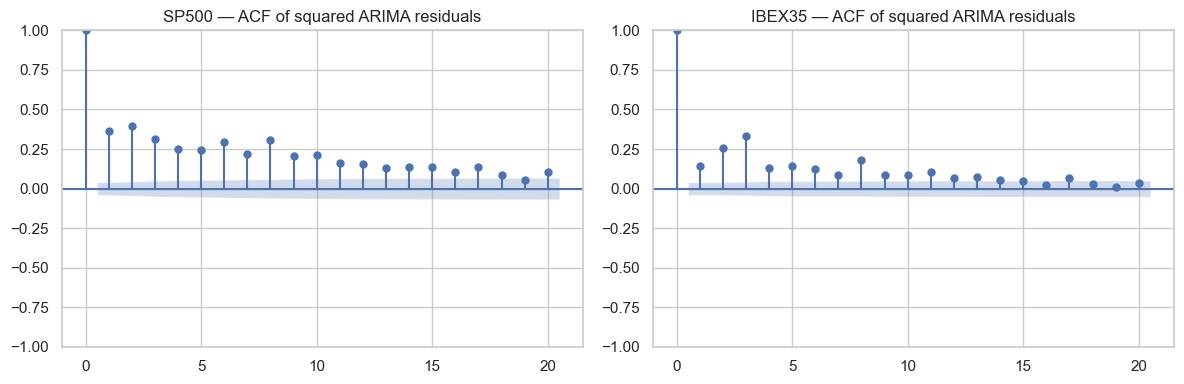

,ARCH-LM stat,ARCH-LM p-value
Series,,
SP500,643.155199,9.884933e-132
IBEX35,420.413513,4.236863e-84


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
arch_rows = []

for j, col in enumerate(log_returns.columns):
    resid = arima_models[col].resid()
    plot_acf(resid ** 2, lags=20, ax=axes[j], title=f"{col} — ACF of squared ARIMA residuals")

    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(resid, nlags=10)
    arch_rows.append({
        "Series": col,
        "ARCH-LM stat": lm_stat,
        "ARCH-LM p-value": lm_pvalue,
    })

plt.tight_layout()
plt.show()

arch_df = pd.DataFrame(arch_rows).set_index("Series")
arch_df


**Interpretation.** This is the key result of the notebook. Where the ACF of
the *raw* residuals (Section 6) was flat and inconclusive, the ACF of the
*squared* residuals is strongly positive and decays slowly over many lags —
visually almost identical to what Stage 1 found for the squared returns
themselves, confirming that the ARIMA mean model, however it filtered the
data, did nothing to remove the volatility clustering (nor should it — that's
not what a mean model is for). The ARCH-LM p-value is effectively zero for
both indices, formally rejecting the null of homoscedastic residuals.

Put together with Section 6: the mean-model residuals are **uncorrelated but
not independent** — serially white in levels, yet strongly dependent in
their squared magnitude. That combination is precisely the setting a GARCH
model is built for: it leaves the (already adequate) mean equation alone and
models the *conditional variance* of these residuals as an autoregressive
process, $\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$,
which is exactly where Stage 3 picks up.


## 8. Summary

1. **Stationarity.** ADF and KPSS agree: price levels are non-stationary,
   log returns are stationary — so ARIMA is applied to returns with $d=0$.
2. **Order identification.** ACF/PACF of returns are close to flat, pointing
   to a low ARIMA order — consistent with returns being close to
   unpredictable in the mean.
3. **Mean model.** AIC-driven order search confirms a small (often near-trivial)
   ARIMA specification; Ljung-Box on its residuals shows no remaining linear
   autocorrelation.
4. **The bridge to GARCH.** Despite clean (uncorrelated) residuals, their
   *squares* are strongly autocorrelated, and the ARCH-LM test firmly rejects
   homoscedasticity. The series is stationary and unpredictable in the mean,
   but has time-varying, persistent variance — the exact gap GARCH is designed
   to fill.

**Next stage:** fit a GARCH(1,1) (and variants) to these ARIMA residuals,
interpret the $\omega, \alpha, \beta$ estimates, and validate with Ljung-Box
on the *standardized* and *squared standardized* residuals.


**Scope note:** this project's limitations (horizon, univariate scope,
distributional assumptions, tail-risk modelling, window length, backtest
refit cadence, transaction costs) are collected in one place at the end of
Stage 5, Section 12 ("Limitations and scope").
